# Digital Image Basics
![# Digital Image Basics](./support_files/session1.png)

## Content
1. Pixels
2. Image Type
3. Image Resolution
4. Image Bit Depth
5. Image Measurements & Histograms

In [ ]:
# Let's start by importing the packages that we will use in the rest of the code below.

import os

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from skimage.io import imread
from PIL import Image

# Also set up path to image so we can use notebook locally and in cloud
path_to_images = os.path.join('Module1', 'data')

## 1. Pixels

Open an image, view it, and select a detailed region to see its numerical values:

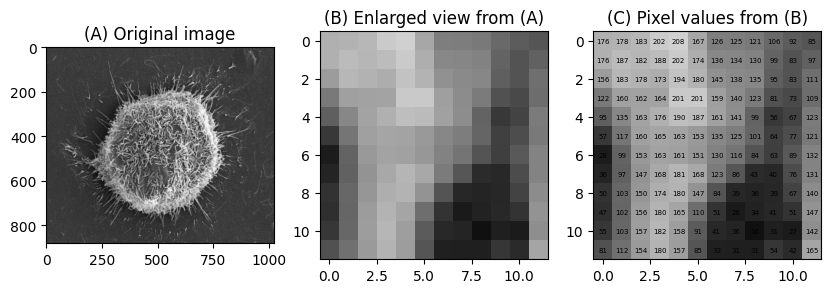

In [ ]:
#  Read image
cell = imread(os.path.join(path_to_images, 'cell.jpg'))

# Select a the detailed region
x, y, width, height = (400, 500, 12, 12)
im_detail = cell[y:y+height, x:x+width]


# Visualize image and its detailed region with pixels values
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10,4))
rect = patches.Rectangle((x, y), width, height, linewidth=1, edgecolor='r', facecolor='none')

ax1.imshow(cell, vmin=0, vmax=255, cmap='gray')
ax1.set_title('(A) Original image')
plt.gca().add_patch(rect)

ax2.imshow(im_detail, vmin=0, vmax=255, cmap='gray')
ax2.set_title('(B) Enlarged view from (A)')

ax3.imshow(im_detail, vmin=0, vmax=255, alpha = 1, cmap='gray')
ax3.set_title('(C) Pixel values from (B)')
for (i, j), z in np.ndenumerate(im_detail):
    ax3.text(j, i, str(z), ha='center', va='center', fontdict={'size': 5})

<span style="color:yellow">**IMPORTANT !**</span>

Always remember that there's a DIFFERENCE between a `pixel's numeric value` and the `color` used to display it. Failing to recognise this difference underlies a *lot* of errors, because:

1.  Images that `look the same` can contain `different` pixel values
2.  Images that `look different` can still contain `the same` pixel values

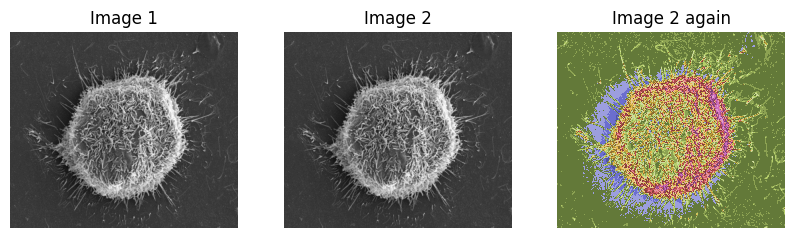

In [3]:
# Create cell2 rescaling cell image in 32-bit
cell2 = (cell.astype(np.float32) - cell.mean()) / cell.std() * 50

# Visualize example
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10,4))

ax1.imshow(cell, cmap='gray')
ax1.set_title('Image 1')
ax1.axis('off')

ax2.imshow(cell2, cmap='gray')
ax2.set_title('Image 2')
ax2.axis('off')

ax3.imshow(cell2, cmap='tab20b')
ax3.set_title('Image 2 again')
ax3.axis('off')
plt.show()

### <span style="color:lightgreen">**EXERCISE**:</br>
These images *look* the same, but they are not. Find a way to prove that the same pixel(s) has different value in the 4 images. </span> 

*Note: Remember that the images are an ndarray of size (881, 1024)*

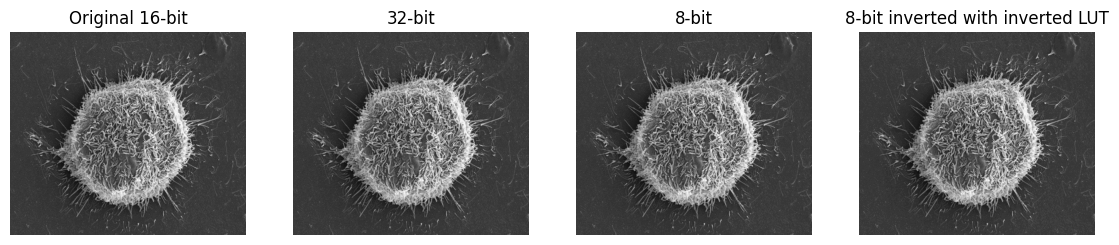

In [4]:
# Create cell3 and cell4 rescaling cell image
cell3 = np.clip(cell, 0, 255)
cell3 = cell3.astype(np.uint8)
cell4 = 255 - cell3

# Visualize the 4 images
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(14,4))
ax1.imshow(cell, cmap='gray')
ax1.set_title('Original 16-bit')
ax1.axis('off')
ax2.imshow(cell2, cmap='gray')
ax2.set_title('32-bit')
ax2.axis('off')
ax3.imshow(cell3, cmap='gray')
ax3.set_title('8-bit')
ax3.axis('off')
ax4.imshow(cell4, cmap='gray_r')
ax4.set_title('8-bit inverted with inverted LUT')
ax4.axis('off')
plt.show()

In [5]:
# YOUR CODE HERE
print(cell[0][0])
print(cell2[0][0])
print(cell3[0][0])
print(cell4[0][0])

44
-39.806004
44
211


___

## 2. Image Type - Color & Channels

We need to distinguish:

- `Grayscale image` : array of 2 dimension (x y)
- `Colored image` : array of 3 dimensions (x y c) where the third one is the color channel (normally c = 3 = RGB)

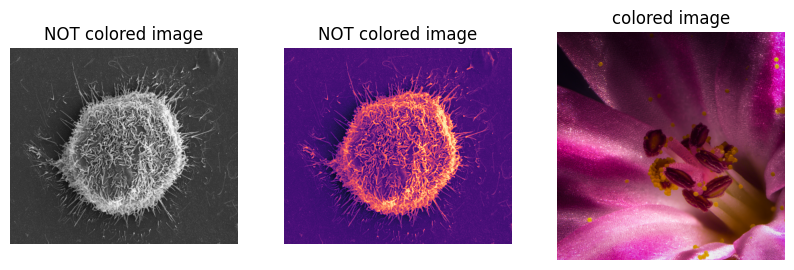

In [ ]:
# Read a colored image
flower = imread(os.path.join(path_to_images, 'flower.tif'))

# Visualize the a GRAYSCALE image in 2 different ways by changing colormap, and a COLORED image.
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10,4))

ax1.imshow(cell, cmap='gray')
ax1.set_title('NOT colored image')
ax1.axis('off')

ax2.imshow(cell, cmap='magma')
ax2.set_title('NOT colored image')
ax2.axis('off')

ax3.imshow(flower, cmap='magma')
ax3.set_title('colored image')
ax3.axis('off')
plt.show()

In [7]:
# Check their dimensions
print(cell.shape)
print(flower.shape)

(881, 1024)
(2753, 2753, 3)


___

### <span style="color:lightgreen">**EXERCISE**:</br>
As we previously studied, the RGB channels of the image can be viewed individually as grayscale image, let's try to do that!

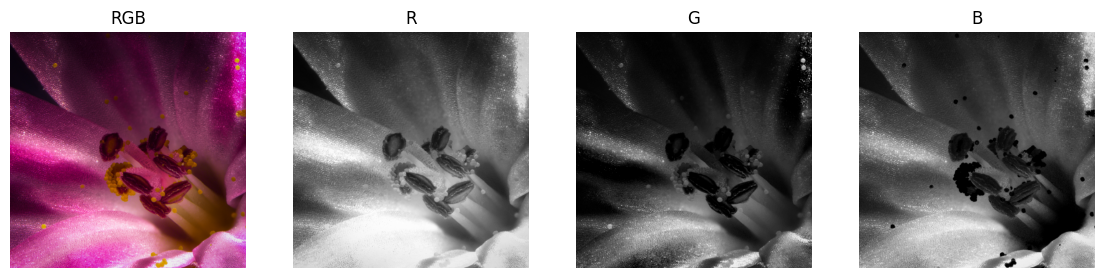

In [8]:
# YOUR CODE HERE
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(14,4))
ax1.imshow(flower) #cmap='Reds'
ax1.set_title('RGB')
ax1.axis('off')

ax2.imshow(flower[:,:,0], cmap='gray') #cmap='Reds'
ax2.set_title('R')
ax2.axis('off')
ax3.imshow(flower[:,:,1], cmap='gray') #cmap='Greens'
ax3.set_title('G')
ax3.axis('off')
ax4.imshow(flower[:,:,2], cmap='gray') #cmap='Blues'
ax4.set_title('B')
ax4.axis('off')

plt.show()

### <span style="color:lightgreen">**EXERCISE**:</br>
Now, try to change color channels order in order to generate this image:</span>
 
<img src="./data/flower_changed.png" alt="drawing" width="150"/>

In [9]:
# YOUR CODE HERE

col1 = flower[:,:,0]
col2 = flower[:,:,1]
col3 = flower[:,:,2]

new_flower = flower.copy()
new_flower[:,:,0] = col2
new_flower[:,:,1] = col3
new_flower[:,:,2] = col1

## 3. Image Resolution

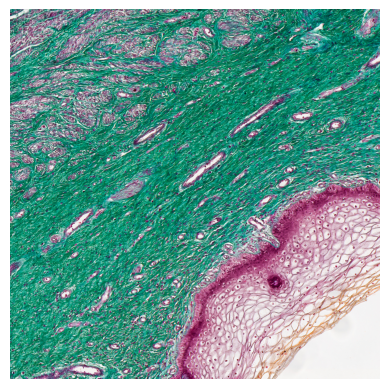

In [ ]:
# Read 'organoid.jpg' image
organoid = Image.fromarray(imread(os.path.join(path_to_images, 'organoid.jpg')))

plt.imshow(organoid)
plt.axis('off')
plt.show()

In [11]:
# Check the original image size
print(organoid.size)

(2609, 2609)


Trying to use `different sizes` to see the differences in the image resolution

(2609, 2609)


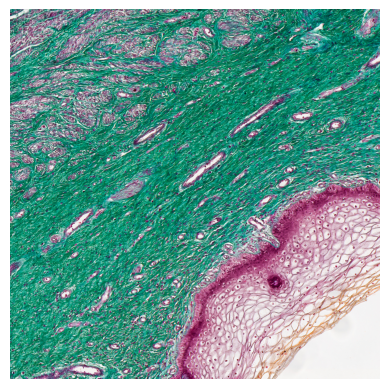

In [12]:
# Resize the organoid
size = (2609, 2609)
im_resized = organoid.resize(size)
print(im_resized.size)

plt.imshow(im_resized)
plt.axis('off')
plt.show()

## 4. Image Bit Depth

The `bit-depth` of a NumPy array is encoded in its data type (`dtype`).

`uint` standa for 'unsigned integer' and `float` for floating-point.

| Type             | Bit-depth | dtype     |
| ---------------- | --------- | --------- |
| Unsigned integer | 8         | `uint8`   |
| Signed integer   | 8         | `int8`    |
| Unsigned integer | 16        | `uint16`  |
| Signed integer   | 16        | `int16`   |
| Unsigned integer | 32        | `uint32`  |
| Signed integer   | 32        | `int32`   |
| Floating point   | 32        | `float32` |
| Floating point   | 64        | `float64` |

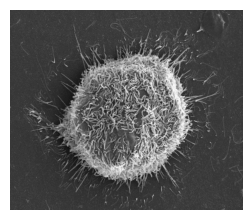

In [13]:
# Visulize cell image
plt.figure(figsize=(3,3))
plt.imshow(cell, cmap='gray')
plt.axis('off')
plt.show()

In [14]:
# Check its data type, and the mean, minumun and maximum values
print(f'dtype: {cell.dtype}')
print(f'Mean: {cell.mean():.2f}')
print(f'Minimum: {cell.min()}')
print(f'Maximum: {cell.max()}')

dtype: uint8
Mean: 79.03
Minimum: 0
Maximum: 255


Rescale the image from uint8 to float32 (which is a bigger bit-depth)

Mean:    79.03
Minimum: 0.0
Maximum: 255.0


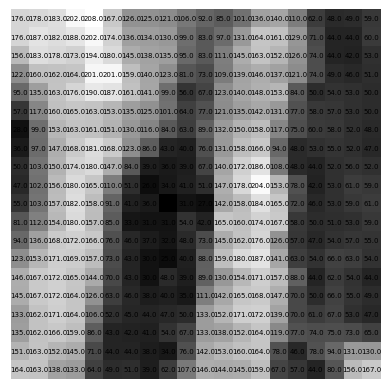

In [27]:
# Rescale the cell image as float32
cell_float = cell.astype(np.float32)
x, y, width, height = (400, 500, 20, 20)
im_detail = cell_float[y:y+height, x:x+width]
# Check its info
print(f'Mean:    {cell_float.mean():.2f}')
print(f'Minimum: {cell_float.min()}')
print(f'Maximum: {cell_float.max()}')
# Visualize the image to see if it looks good
plt.figure()
plt.imshow(im_detail, cmap='gray')
for (i, j), z in np.ndenumerate(im_detail):
    plt.text(j, i, str(round(z,1)), ha='center', va='center', fontdict={'size': 5})
plt.axis('off')
plt.show()

But what about if we try to pass from unsigned to integer values?

Mean:    41.07
Minimum: -128
Maximum: 127


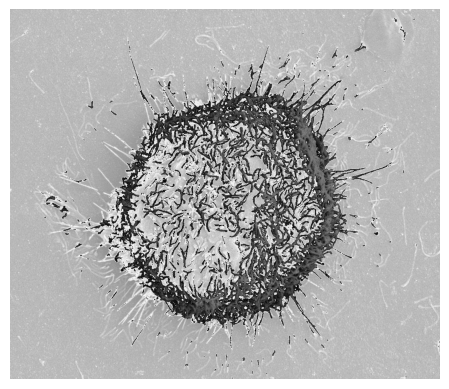

In [35]:
# Rescale the cell image as int8
cell_i8 = cell.astype(np.int8)
x, y, width, height = (400, 500, 20, 20)
im_detail = cell_i8[y:y+height, x:x+width]
# Check its info
print(f'Mean:    {cell_i8.mean():.2f}')
print(f'Minimum: {cell_i8.min()}')
print(f'Maximum: {cell_i8.max()}')
# Visualize the image to see if it looks good
plt.figure()
plt.imshow(cell_i8, cmap='gray')
plt.axis('off')
plt.show()

### <span style="color:lightgreen">**EXERCISE**:</br>
Try to make the image look the same as the previous one.</br>
*Remember that before we were in 0/255 range, and now in -128/127*

Mean:    -48.15
Minimum: -128
Maximum: 127


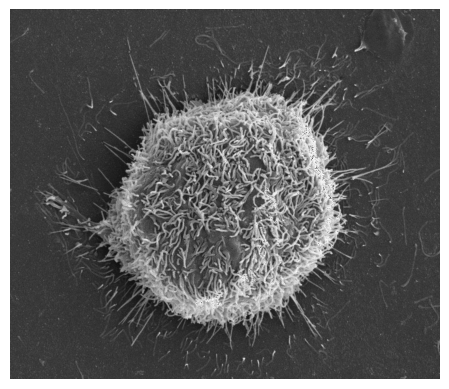

In [36]:
cell_i8 = cell_i8 - 127
# Check its info
print(f'Mean:    {cell_i8.mean():.2f}')
print(f'Minimum: {cell_i8.min()}')
print(f'Maximum: {cell_i8.max()}')
# Visualize the image to see if it looks good
plt.figure()
plt.imshow(cell_i8, cmap='gray')
plt.axis('off')
plt.show()

## 5. Image Measurements & Histograms

Here, we will explore how to make measurements and generate histograms

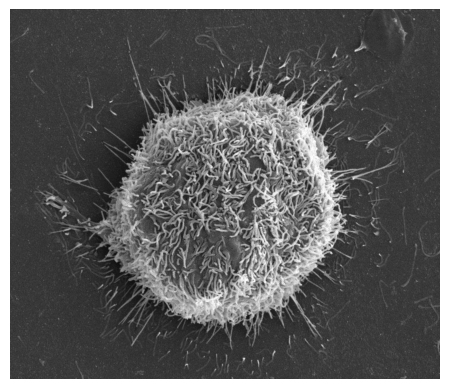

Mean:     79.031
Minimum:  0.0
Maximum:  255.00
Std.dev.: 44.003


In [18]:
plt.imshow(cell, cmap='gray')
plt.axis('off')
plt.show()

print(f'Mean:     {cell.mean():.3f}')
print(f'Minimum:  {cell.min():.1f}')
print(f'Maximum:  {cell.max():.2f}')
print(f'Std.dev.: {cell.std():.3f}')


We ca try to generate image histograms, using `plt.hist`.

You might expect `plt.hist(im)` to work, just as `plt.imshow(im)` did previously, but the result can be a bit surprising

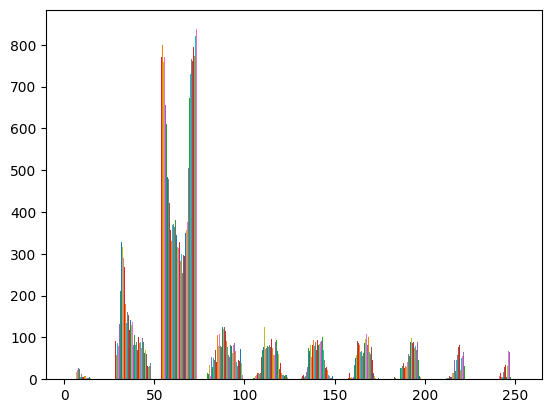

In [19]:
plt.hist(cell)
plt.show()

The problem is that the image is 2D, and `plt.hist` is expecting just a single 1D list of values</br>
We can generate that with a call to `.flatten()`, and use the flattened array to create the histogram

Shape before flatten(): (881, 1024)
Shape after flatten(): (902144,)


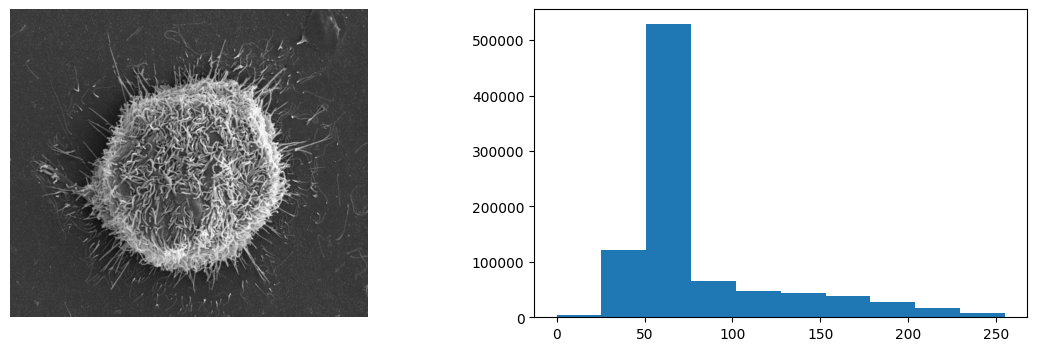

In [20]:
print(f'Shape before flatten(): {cell.shape}')
im_flat = cell.flatten()
print(f'Shape after flatten(): {im_flat.shape}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,4))
ax1.imshow(cell, cmap='gray')
ax1.axis('off')
ax2.hist(im_flat)
plt.show()

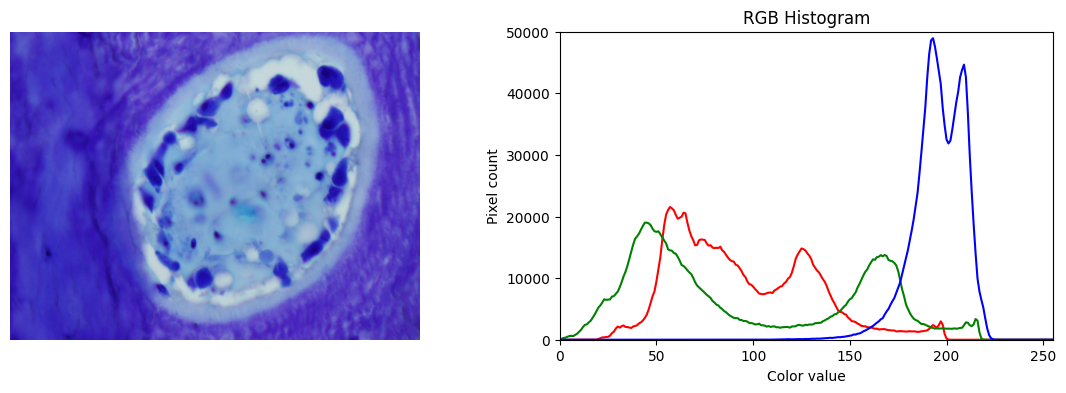

In [ ]:
bone = imread(os.path.join(path_to_images, 'bone.tif'))
colors = ("red", "green", "blue")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,4))
ax1.imshow(bone, cmap='gray')
ax1.axis('off')

ax2.set_xlim([0, 255])
ax2.set_ylim([0,50000])
for channel_id, color in enumerate(colors):
    histogram, bin_edges = np.histogram(bone[:, :, channel_id], bins=256, range=(0, 256))
    ax2.plot(bin_edges[0:-1], histogram, color=color)
ax2.set_title("RGB Histogram")
ax2.set_xlabel("Color value")
ax2.set_ylabel("Pixel count")

plt.show()

____
### <span style="color:lightgreen">**BONUS EXERCISE**:</br>
Open images bw1.png, bw2.png, bw3.png and bw4.png. They look the same, but actually only two on them are really identical</br>
Can you guess which ones?</span>

In [ ]:
bw1 = imread(os.path.join(path_to_images, 'bw1.png'))
bw2 = imread(os.path.join(path_to_images, 'bw2.png'))
bw3 = imread(os.path.join(path_to_images, 'bw3.png'))
bw4 = imread(os.path.join(path_to_images, 'bw4.png'))


print(np.all(bw1 == bw2))
print(np.all(bw1 == bw3))
print(np.all(bw1 == bw4))
print(np.all(bw2 == bw3))
print(np.all(bw2 == bw4))# -> True
print(np.all(bw3 == bw4))

False
False
False
False
True
False
